In [49]:
import pandas as pd
import numpy as np
import re
import random
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
random.seed(42)
np.random.seed(42)

## سوال ۷ — خواندن دادگان و پیش‌پردازش متون

فایل `dataset.csv` شامل دو ستون است:
- `Text`: متن خبر
- `Label`: برچسب موضوعی خبر (۰ تا ۴)

پیش‌پردازش شامل موارد زیر است:
1. کوچک کردن تمامی حروف (lowercase)
2. حذف علائم نگارشی و کاراکترهای غیرحرفی (اعداد، نشانه‌ها و...)
3. یکدست‌سازی فاصله‌های خالی (whitespace)

In [50]:
df = pd.read_csv('dataset.csv')
print("ابعاد دادگان:", df.shape)
df.head()

ابعاد دادگان: (2225, 2)


,Text,Label
0,Budget to set scene for election\n \n Gordon B...,0
1,Army chiefs in regiments decision\n \n Militar...,0
2,Howard denies split over ID cards\n \n Michael...,0
3,Observers to monitor UK election\n \n Minister...,0
4,Kilroy names election seat target\n \n Ex-chat...,0


In [51]:
def preprocess(text: str) -> str:
    """حذف علائم نگارشی، کوچک‌سازی حروف و یکدست‌سازی فاصله‌ها"""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)   # حذف هر چیزی به‌جز حروف انگلیسی و فاصله
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['Text'].apply(preprocess)

print("نمونه متن خام:\n", df['Text'].iloc[0][:300])
print("\nنمونه متن پیش‌پردازش‌شده:\n", df['clean_text'].iloc[0][:300])

نمونه متن خام:
 Budget to set scene for election
 
 Gordon Brown will seek to put the economy at the centre of Labour's bid for a third term in power when he delivers his ninth Budget at 1230 GMT. He is expected to stress the importance of continued economic stability, with low unemployment and interest rates. The 

نمونه متن پیش‌پردازش‌شده:
 budget to set scene for election gordon brown will seek to put the economy at the centre of labour s bid for a third term in power when he delivers his ninth budget at gmt he is expected to stress the importance of continued economic stability with low unemployment and interest rates the chancellor 


## سوال ۸ — ۳۰ کلمه پرتکرار

در این بخش با شمارش تمامی کلمات موجود در تمام متون (پس از پیش‌پردازش)، ۳۰ کلمه پرتکرار استخراج و نمودار ستونی فراوانی آن‌ها رسم می‌شود.

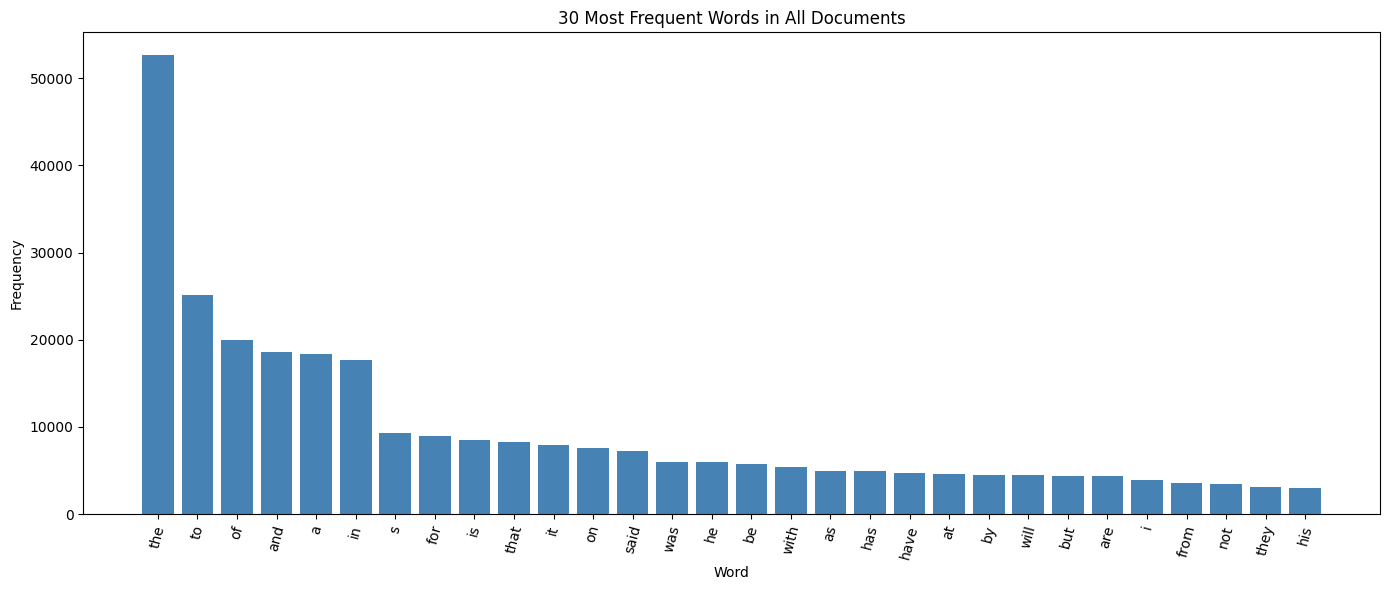

         the : 52636
          to : 25113
          of : 20008
         and : 18612
           a : 18343
          in : 17734
           s : 9310
         for : 8945
          is : 8555
        that : 8257
          it : 7893
          on : 7625
        said : 7255
         was : 6028
          he : 5939
          be : 5805
        with : 5354
          as : 4981
         has : 4957
        have : 4772
          at : 4638
          by : 4516
        will : 4473
         but : 4421
         are : 4401
           i : 3909
        from : 3535
         not : 3484
        they : 3085
         his : 3026


In [52]:
all_words = ' '.join(df['clean_text']).split()
word_counts = Counter(all_words)

top_30 = word_counts.most_common(30)
words_30, freqs_30 = zip(*top_30)

plt.figure(figsize=(14, 6))
plt.bar(words_30, freqs_30, color='steelblue')
plt.xticks(rotation=75)
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.title('30 Most Frequent Words in All Documents')
plt.tight_layout()
plt.show()

for w, f in top_30:
    print(f"{w:>12} : {f}")

**آیا دانستن تعداد این کلمات در یک خبر، کمکی به درک موضوع آن خبر می‌کند؟**

خیر. همان‌طور که در نمودار بالا مشخص است، کلمات پرتکرار عمدتاً کلمات ربط، حروف اضافه و افعال کمکی/اسنادی
پرکاربرد زبان انگلیسی هستند (مانند `the`, `to`, `of`, `and`, `a`, `in`, `is` و...). این کلمات تقریباً در
همهٔ متون با فراوانی بالا و مشابه ظاهر می‌شوند و به موضوع خاص یک متن مرتبط نیستند؛ بنابراین دانستن تعداد
تکرار آن‌ها اطلاعات تمایزدهنده‌ای دربارهٔ موضوع خبر نمی‌دهد. برای درک موضوع، باید به کلمات کلیدی و
پرمعناتر (مانند اسامی خاص یا کلمات موضوعی) توجه کرد، نه پرتکرارترین کلمات کل دادگان.

## سوال ۹ — نمودار ابر کلمات (Word Cloud)

برای ساخت ابر کلمات معنادار، معمولاً کلمات توقف (Stop Words — کلمات بسیار پرتکرار و کم‌معنا مانند
`the`, `is`, `and` و...) حذف می‌شوند تا کلمات کلیدی و پرمعناتر متون نمایان شوند. اندازهٔ هر کلمه در
ابر کلمات متناسب با فراوانی (یا اهمیت) آن کلمه در متن است.

از آنجا که در محیط اجرا دسترسی به اینترنت برای نصب پکیج `wordcloud` وجود نداشت، یک نسخهٔ ساده از
الگوریتم ابر کلمات با matplotlib پیاده‌سازی شده است: کلمات پرتکرار (پس از حذف stop words) با اندازهٔ
متناسب با فراوانی، در موقعیت‌های تصادفی نمایش داده می‌شوند.

In [53]:
# فهرست کلمات توقف رایج در زبان انگلیسی
STOPWORDS = set("""
a about above after again against all am an and any are aren't as at be because been before being
below between both but by can't cannot could couldn't did didn't do does doesn't doing don't down
during each few for from further had hadn't has hasn't have haven't having he he'd he'll he's her
here here's hers herself him himself his how how's i i'd i'll i'm i've if in into is isn't it it's
its itself let's me more most mustn't my myself no nor not of off on once only or other ought our
ours ourselves out over own same shan't she she'd she'll she's should shouldn't so some such than
that that's the their theirs them themselves then there there's these they they'd they'll they're
they've this those through to too under until up very was wasn't we we'd we'll we're we've were
weren't what what's when when's where where's which while who who's whom why why's with won't
would wouldn't you you'd you'll you're you've your yours yourself yourselves said also mr one two
new will us
""".split())

filtered_words = [w for w in all_words if w not in STOPWORDS and len(w) > 2]
cloud_counts = Counter(filtered_words)
top_cloud_words = cloud_counts.most_common(150)

print("۱۰ کلمهٔ برتر پس از حذف کلمات توقف:")
for w, f in top_cloud_words[:10]:
    print(f"{w:>12} : {f}")

۱۰ کلمهٔ برتر پس از حذف کلمات توقف:
        year : 2310
      people : 2045
         can : 1671
        last : 1394
       first : 1355
        time : 1322
       world : 1201
  government : 1160
         now : 1145
       years : 1003


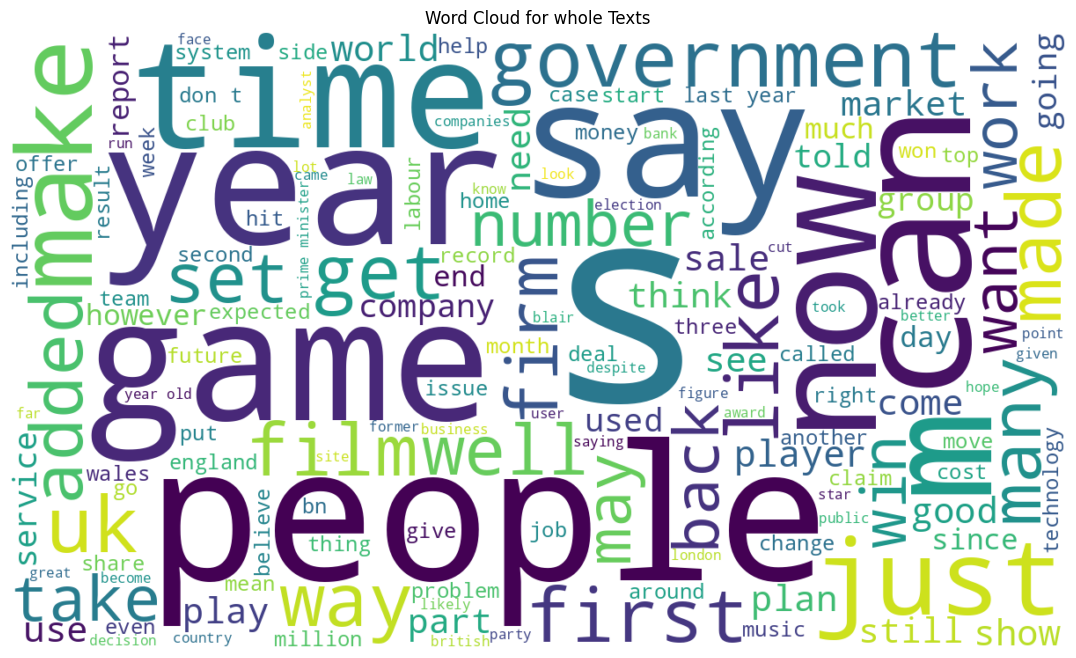

In [54]:
wc = WordCloud(width=1200, height=700, background_color='white',
                stopwords=STOPWORDS, max_words=150).generate(' '.join(df['clean_text']))

plt.figure(figsize=(14, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for whole Texts')
plt.show()

**تفسیر نمودار و معیار انتخاب کلمات:**

در الگوریتم ابر کلمات، معیار اصلی برای انتخاب و بزرگ‌نمایی هر کلمه، **فراوانی تکرار** آن در کل متون
است (پس از حذف کلمات توقف و علائم نگارشی)؛ هرچه کلمه‌ای بیشتر تکرار شده باشد، با فونت بزرگ‌تر و
معمولاً رنگ پررنگ‌تری نمایش داده می‌شود. موقعیت قرارگیری کلمات معمولاً تصادفی است و اهمیت معنایی
خاصی ندارد. با نگاه به ابر کلمات می‌توان به سرعت **موضوعات و مفاهیم غالب** در مجموعه متون را حدس
زد؛ کلماتی مانند `year`, `people`, `government`, `game` و... که در نمودار درشت‌تر دیده می‌شوند،
نشان‌دهندهٔ محورهای اصلی محتوای خبری این دادگان (مانند سیاست، ورزش و اقتصاد) هستند.

## سوال ۱۰ — ساخت ماتریس کوله کلمات (Bag of Words)

فایل `words.csv` شامل مجموعه‌ای از کلمات منتخب (به ترتیب الفبا) است که با همان روش استخراج کلمات
ابر کلمات به‌دست آمده‌اند. در این بخش، برای هر متن، تعداد تکرار هر یک از این کلمات شمارش شده و
ماتریس کوله کلمات (BW) ساخته می‌شود؛ ماتریسی با ابعاد (تعداد متون × تعداد کلمات منتخب) که درایهٔ
$f_{i,j}$ آن، تعداد تکرار کلمهٔ $j$ ام در متن $i$ ام است.

In [55]:
words_df = pd.read_csv('words.csv')
selected_words = words_df['Words'].str.lower().tolist()

print("تعداد کلمات منتخب:", len(selected_words))
print(selected_words)

تعداد کلمات منتخب: 52
['artist', 'chief', 'china', 'club', 'company', 'computer', 'country', 'deal', 'digital', 'director', 'economy', 'election', 'expected', 'film', 'firm', 'france', 'game', 'government', 'group', 'growth', 'help', 'high', 'home', 'industry', 'labour', 'law', 'market', 'match', 'million', 'minister', 'mobile', 'money', 'music', 'new', 'number', 'office', 'old', 'online', 'party', 'phone', 'play', 'record', 'sale', 'service', 'tax', 'technology', 'time', 'uk', 'user', 'win', 'won', 'work']


In [56]:
n_docs = len(df)
n_words = len(selected_words)

BW = np.zeros((n_docs, n_words), dtype=int)

for i, text in enumerate(df['clean_text']):
    token_counts = Counter(text.split())
    for j, w in enumerate(selected_words):
        BW[i, j] = token_counts.get(w, 0)

BW_df = pd.DataFrame(BW, columns=selected_words)

print("ابعاد ماتریس کوله کلمات (BW):", BW_df.shape)
BW_df.head()

ابعاد ماتریس کوله کلمات (BW): (2225, 52)


,artist,chief,china,club,company,computer,country,deal,digital,director,...,sale,service,tax,technology,time,uk,user,win,won,work
0,0,1,0,0,0,0,0,0,0,0,...,0,0,6,0,2,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,3,0,0,0,1
4,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,3,0,0,2,0


ماتریس کوله کلمات ساخته‌شده، ابعادی برابر با **(۲۲۲۵ × ۵۲)** دارد؛ یعنی به ازای هر یک از ۲۲۲۵ متن
دادگان، یک بردار ۵۲ بعدی (متناظر با ۵۲ کلمهٔ منتخب فایل `words.csv`) ساخته شده که هر درایهٔ آن،
تعداد تکرار کلمهٔ مربوطه در آن متن است. این ماتریس در سوالات بعدی (استانداردسازی و تجزیهٔ SVD)
مورد استفاده قرار خواهد گرفت.